# Purpose
The purpose of this notebook is to fully analyze the cleaned and filtered faculty data parquet file. 

Please run the filter_and_sort.ipynb to obtain the parquet file. Alternatively get the data from  [Google Drive](https://drive.google.com/drive/folders/1JIC3yfQ-2-siGTgWW8LAvi-2jwqDDESW?usp=drive_link)

## Load Data

In [2]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

df = pl.read_parquet("data/cleaned_salaries.parquet")
duckdb.connect()

duckdb.sql(f"""
CREATE OR REPLACE TABLE faculty_salaries AS
    SELECT *
    FROM df
    """)

## General Faculty EDA

In [3]:
df.describe()

statistic,year,campus,first_name,last_name,title_name,department,gross_pay,base_pay,overtime_pay,other_pay
str,f64,str,str,str,str,str,f64,f64,f64,f64
"""count""",246331.0,"""246331""","""246331""","""246331""","""246331""","""246331""",246331.0,246331.0,246331.0,246331.0
"""null_count""",0.0,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",2018.896018,null,null,null,null,null,207881.196208,138879.031494,80.769469,68921.395691
"""std""",3.422542,null,null,null,null,null,155684.505751,69337.785574,1245.173895,119502.582197
"""min""",2013.0,"""berkeley""",""" aamir""","""****""","""acad achievement cnslr 4""","""Agriculture, Food & Animal""",27496.0,35152.0,-1975.0,-345255.0
"""25%""",2016.0,null,null,null,null,null,106808.0,91083.0,0.0,625.0
"""50%""",2019.0,null,null,null,null,null,168392.0,127333.0,0.0,25556.0
"""75%""",2022.0,null,null,null,null,null,263283.0,173904.0,0.0,85393.0
"""max""",2024.0,"""uc sf law""","""zyrene""","""zyzik ""","""writer sr""","""Social Sciences & Communicatio…",3.974061e6,838117.0,94536.0,3.695451e6


#### Get number of Schools and Faculty Accounted for

In [12]:
duckdb.sql("""
SELECT DISTINCT campus
FROM faculty_salaries  
""").pl()

campus
str
"""san diego"""
"""san francisco"""
"""los angeles"""
"""uc sf law"""
"""davis"""
"""irvine"""
"""riverside"""
"""santa barbara"""
"""santa cruz"""


In [16]:
duckdb.sql("""
SELECT COUNT(DISTINCT CONCAT(TRIM(first_name), ' ', TRIM(last_name), ' ', campus))
FROM faculty_salaries  
""").pl()

"count(DISTINCT concat(main.""trim""(first_name), ' ', main.""trim""(last_name), ' ', campus))"
i64
56124


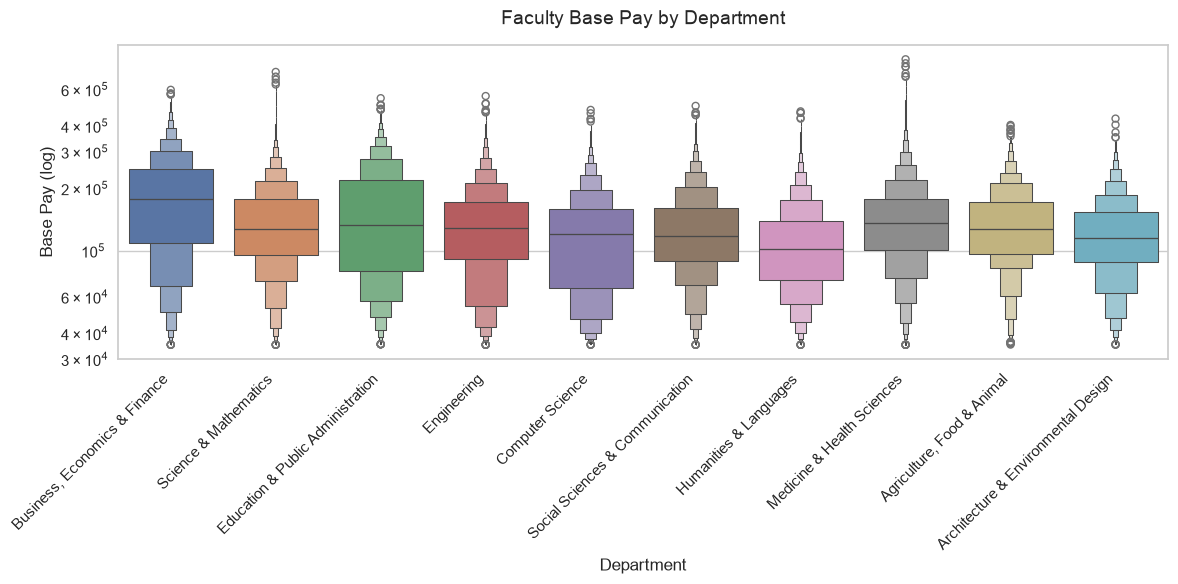

In [5]:
pay_by_salary = duckdb.sql("""
SELECT base_pay, gross_pay, department
FROM faculty_salaries
""").pl()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxenplot(
    data=pay_by_salary, 
    x="department",
    y='base_pay',
    hue="department",
    log_scale=True
)

plt.title("Faculty Base Pay by Department", fontsize=14, pad=15)
plt.xlabel("Department", fontsize=12)
plt.ylabel("Base Pay (log)", fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Methodology Note
Since our dataset spans 2013-2042 and we have no access (as of 9/19/26) to origional hire dates, faculty tenures are measured starting from 2014. This ensures that "year 1" salaries acutally represent a given faculties initial year of employment and not just a first observation of an existing employee. 

TLDR: This analysis samples faculty whose (name + campus) was first recorded strictly after 2013

In [6]:
pay_trajectory = duckdb.sql("""
WITH base_data AS (
    SELECT 
        CONCAT(first_name, ' ', last_name) as identity, campus,
        ANY_VALUE(base_pay) AS pay,
        department, title_name, year
    FROM faculty_salaries
    GROUP BY identity, campus, department, title_name, year
),
collision_check AS (
    SELECT *,
        COUNT(*) OVER (PARTITION BY identity, campus, year) AS appearances_in_year
    FROM base_data
),
valid_faculty AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY identity, campus ORDER BY year) as tenure_year,
        MIN(year) OVER (partition BY identity, campus) as first_appearance
    FROM collision_check
    WHERE appearances_in_year = 1 -- makes sure there arent any collisions
)
SELECT identity, campus, department, title_name, year, pay, tenure_year, first_appearance as hire_year
FROM valid_faculty
WHERE first_appearance > 2013 AND tenure_year <= 10
ORDER BY tenure_year DESC                  
""").pl()

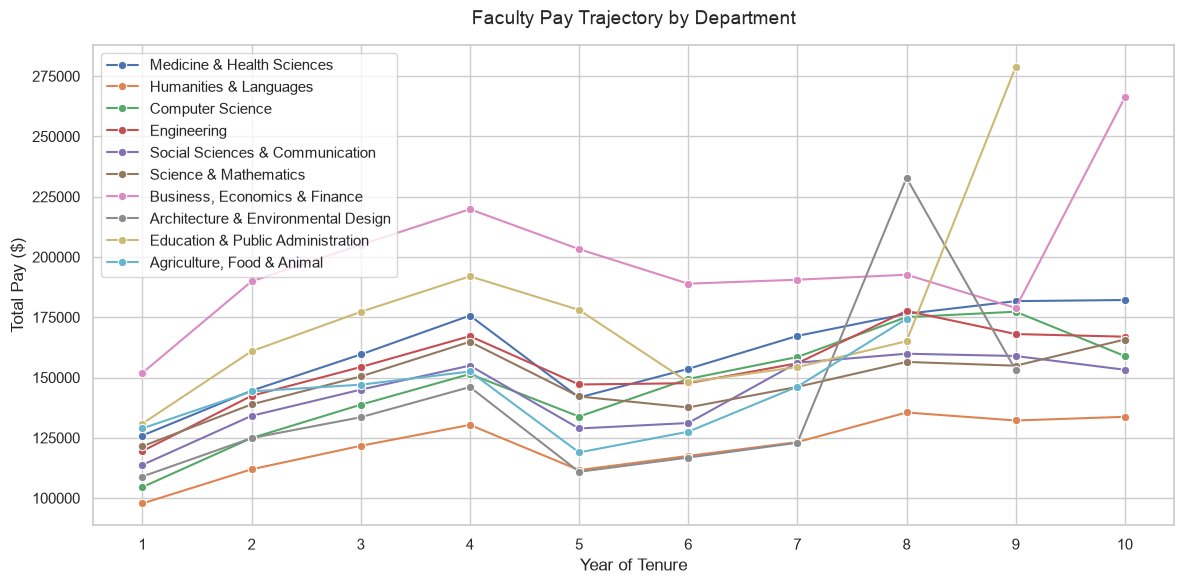

In [7]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=pay_trajectory, 
    x="tenure_year", 
    y="pay", 
    hue="department",
    marker="o",
    errorbar=None
)

plt.title("Faculty Pay Trajectory by Department", fontsize=14, pad=15)
plt.xlabel("Year of Tenure", fontsize=12)
plt.ylabel("Total Pay ($)", fontsize=12)

plt.xticks(range(1, 11))

plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Finding a reason for the spikes 

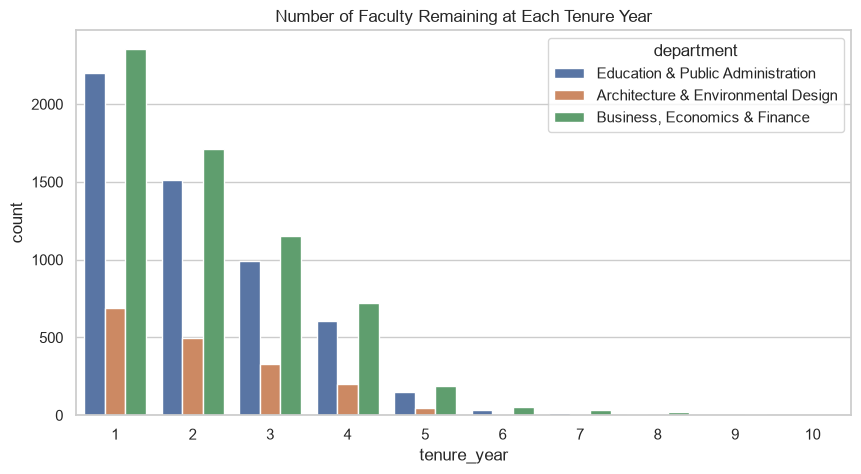

In [8]:
# Explore the weird spikes

weird_depts = ['Education & Public Administration', 'Business, Economics & Finance', 'Architecture & Environmental Design']
weird_data = pay_trajectory.filter(pl.col('department').is_in(weird_depts))

plt.figure(figsize=(10, 5))

sns.countplot(
    data=weird_data,
    x="tenure_year", 
    hue="department"
)
plt.title("Number of Faculty Remaining at Each Tenure Year")
plt.show()

In [9]:
pl.Config.set_tbl_rows(26)

duckdb.sql("""
SELECT COUNT(*), department, tenure_year
FROM pay_trajectory -- weird_data
WHERE tenure_year > 7
GROUP BY department, tenure_year 
ORDER BY tenure_year
""").pl()

count_star(),department,tenure_year
i64,str,i64
33,"""Engineering""",8
82,"""Science & Mathematics""",8
8,"""Education & Public Administrat…",8
20,"""Social Sciences & Communicatio…",8
2,"""Architecture & Environmental D…",8
34,"""Computer Science""",8
327,"""Medicine & Health Sciences""",8
18,"""Business, Economics & Finance""",8
50,"""Humanities & Languages""",8


### Only 7 departments have people who have been around for ten years between 2013 and 2024

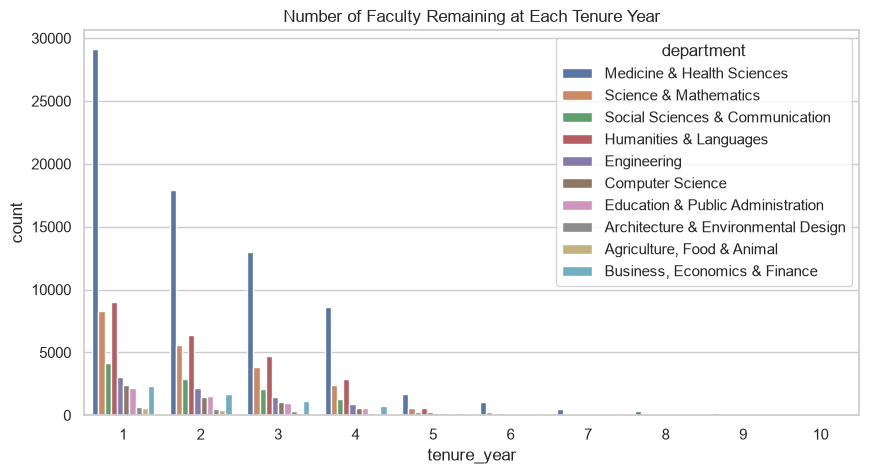

In [10]:
# With all departments 

plt.figure(figsize=(10, 5))

sns.countplot(
    data=pay_trajectory,
    x="tenure_year", 
    hue="department",
    stat="count"
    # log_scale=True,

)
plt.title("Number of Faculty Remaining at Each Tenure Year")
plt.show()

#### The spikes in the data are due to the low amount of people in those departments with long tenures.

#### For the above graph to be more legible the data must be normalized

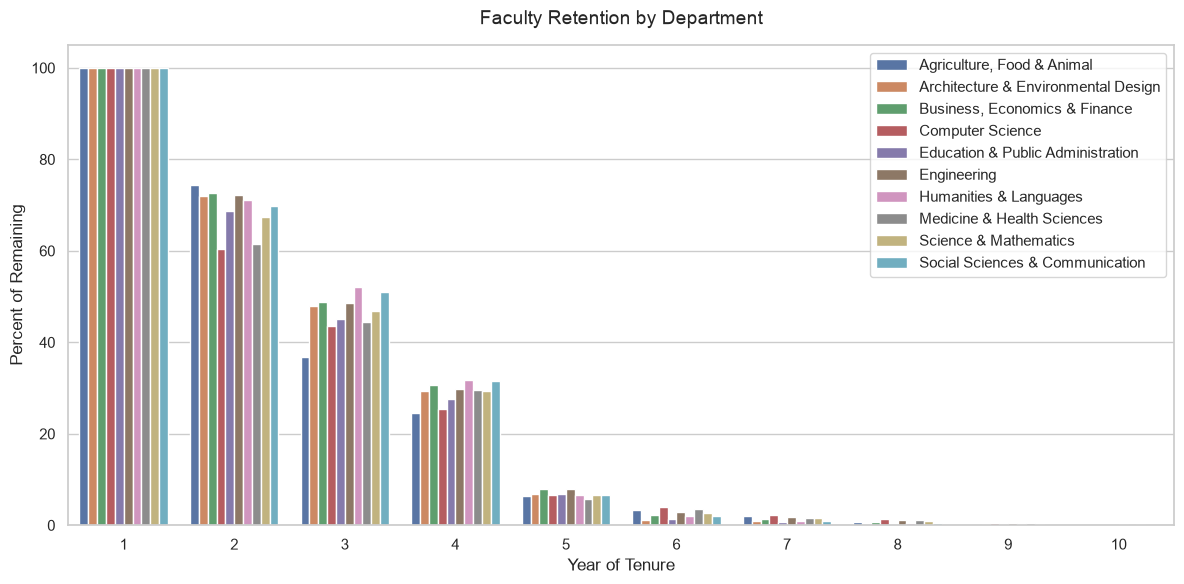

In [11]:
# Normalized retention

retention_df = duckdb.sql("""
WITH dept_counts AS (
    SELECT department, tenure_year, 
        COUNT(*) AS faculty_count
    FROM pay_trajectory
    GROUP BY department, tenure_year
)
SELECT department, tenure_year, faculty_count,
    (faculty_count * 100.0) / FIRST_VALUE(faculty_count) OVER (
        PARTITION BY department 
        ORDER BY tenure_year
    ) AS retained
FROM dept_counts
ORDER BY department, tenure_year
""").pl()

plt.figure(figsize=(12, 6))

sns.barplot(
    data=retention_df,
    x="tenure_year", 
    y="retained",
    hue="department"
)

plt.title("Faculty Retention by Department", fontsize=14, pad=15)
plt.xlabel("Year of Tenure", fontsize=12)
plt.ylabel("Percent of Remaining", fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## TODO make more pretty graphs and eventually add data from CSUs